# Task 16 — Customer Feedback Analysis System Using NLP

### Dataset: `finalReviews.csv`

This notebook implements a **classical NLP sentiment-analysis pipeline** using the supplied dataset.

**Pipeline:**

`Raw Review → Text Cleaning → TF-IDF + N-grams → Logistic Regression → Sentiment → Keywords → Evaluation`

The supplied dataset contains `review` and binary `label` columns. Therefore, this notebook trains **sentiment classification**. A supervised complaint/category model is not trained because the dataset does not contain a category column.

## 1. Import Libraries

We use pandas for data handling, regular expressions for text cleaning, scikit-learn for TF-IDF and classification, and matplotlib for visualization.

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)
RANDOM_STATE = 42

## 2. Load the Dataset

The cell below works in common notebook environments. If necessary, change `DATA_PATH` to the location of `finalReviews.csv`.

In [9]:
import pandas as pd
import os

DATA_PATH = r"C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 16 - Building a Customer Feedback Analysis System Using NLP\S.GayathriG40-AIML\finalReviews.csv"

# Check whether the file exists
print("File exists:", os.path.exists(DATA_PATH))

# Load dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

File exists: True
Dataset loaded successfully!
Shape: (302, 2)


,review,label
0,"There isn't too much in the way of suspense or surprises when it comes to the story, but there are some shocking moments and funny lines in this epic finale. Again, like many of the best Marvel fi...",1
1,"I cried and laughed and blah, blah, blah. CGI was great, but I can't get past all the subtext to create plot rules and then completley blow them put of the water. I can think of about 5 minutes of...",1
2,Not as good as infinity war..,1
3,"First review from me. This film deserves it. A superhero film, marvel or not, does not have the right to send me on the emotional rollercoaster that End Game did. It has no right to do what it did...",1
4,This film is an emotional rollercoaster with some of the coolest superhero plot lines ever drawn up. It's straight up the most epic Marvel film that will probably ever be created. I don't see how ...,1


## 3. Understand the Dataset

We check columns, data types, missing values, duplicates, and the target-label distribution.

In [10]:
print("Columns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nLabel counts:\n", df["label"].value_counts().sort_index())

Columns: ['review', 'label']

Data types:
 review      str
label     int64
dtype: object

Missing values:
 review    0
label     0
dtype: int64

Duplicate rows: 0

Label counts:
 label
0    132
1    170
Name: count, dtype: int64


count    302.000000
mean      81.715232
std      126.013598
min        1.000000
25%       11.000000
50%       33.500000
75%       94.000000
max      877.000000
Name: review, dtype: float64


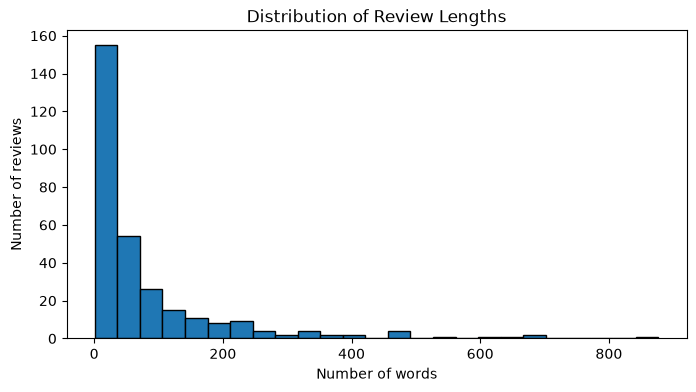

In [11]:
# Basic review-length statistics
review_lengths = df["review"].astype(str).str.split().str.len()
print(review_lengths.describe())

plt.figure(figsize=(8, 4))
plt.hist(review_lengths, bins=25, edgecolor="black")
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")
plt.show()

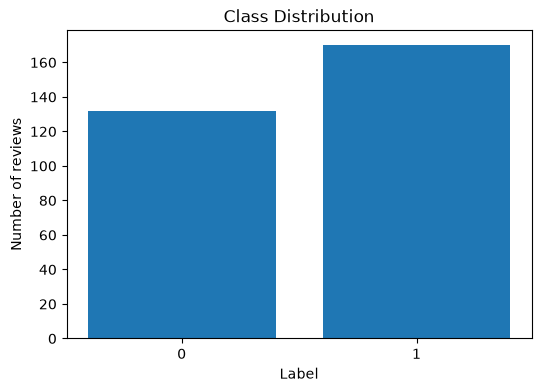

In [12]:
label_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of reviews")
plt.show()

## 4. Clean the Data

For sentiment analysis we avoid aggressive cleaning. In particular, negation words such as **not**, **no**, and **never** should be preserved because they can change sentiment.

In [13]:
def clean_text(text):
    """Light text cleaning that preserves sentiment-bearing words."""
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)                 # remove HTML
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)  # normalize URLs
    text = re.sub(r"\S+@\S+", " EMAIL ", text)        # normalize emails
    text = re.sub(r"[^a-z0-9'!?\s]", " ", text)       # retain apostrophes and ! ?
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Remove unusable rows and exact duplicates
df = df.dropna(subset=["review", "label"]).copy()
df = df.drop_duplicates().reset_index(drop=True)

df["clean_review"] = df["review"].apply(clean_text)
df = df[df["clean_review"].str.len() > 0].reset_index(drop=True)

print("Shape after cleaning:", df.shape)
df[["review", "clean_review", "label"]].head()

Shape after cleaning: (302, 3)


,review,clean_review,label
0,"There isn't too much in the way of suspense or surprises when it comes to the story, but there are some shocking moments and funny lines in this epic finale. Again, like many of the best Marvel fi...",there isn't too much in the way of suspense or surprises when it comes to the story but there are some shocking moments and funny lines in this epic finale again like many of the best marvel films...,1
1,"I cried and laughed and blah, blah, blah. CGI was great, but I can't get past all the subtext to create plot rules and then completley blow them put of the water. I can think of about 5 minutes of...",i cried and laughed and blah blah blah cgi was great but i can't get past all the subtext to create plot rules and then completley blow them put of the water i can think of about 5 minutes of scen...,1
2,Not as good as infinity war..,not as good as infinity war,1
3,"First review from me. This film deserves it. A superhero film, marvel or not, does not have the right to send me on the emotional rollercoaster that End Game did. It has no right to do what it did...",first review from me this film deserves it a superhero film marvel or not does not have the right to send me on the emotional rollercoaster that end game did it has no right to do what it did payi...,1
4,This film is an emotional rollercoaster with some of the coolest superhero plot lines ever drawn up. It's straight up the most epic Marvel film that will probably ever be created. I don't see how ...,this film is an emotional rollercoaster with some of the coolest superhero plot lines ever drawn up it's straight up the most epic marvel film that will probably ever be created i don't see how ma...,1


## 5. Label Mapping

This notebook uses the common binary mapping **0 = Negative** and **1 = Positive**. If the dataset provider uses another definition, change only the dictionary below.

In [14]:
LABEL_MAP = {
    0: "Negative",
    1: "Positive"
}

df["sentiment"] = df["label"].map(LABEL_MAP)
print(df[["label", "sentiment"]].value_counts().sort_index())

label  sentiment
0      Negative     132
1      Positive     170
Name: count, dtype: int64


## 6. Train/Test Split

The test set is kept separate from training data so that we can evaluate performance on unseen reviews. `stratify=y` preserves the class ratio.

In [15]:
X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print("\nTraining label distribution:\n", y_train.value_counts(normalize=True).sort_index())

Training samples: 241
Testing samples : 61

Training label distribution:
 label
0    0.435685
1    0.564315
Name: proportion, dtype: float64


## 7. Baseline: Bag of Words + Logistic Regression

Bag of Words is a useful baseline before TF-IDF.

In [16]:
bow_model = Pipeline([
    ("bow", CountVectorizer(ngram_range=(1, 1), min_df=1)),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

bow_model.fit(X_train, y_train)
bow_pred = bow_model.predict(X_test)

bow_accuracy = accuracy_score(y_test, bow_pred)
print(f"Bag of Words Accuracy: {bow_accuracy:.4f}")

Bag of Words Accuracy: 0.7541


## 8. TF-IDF + N-grams + Logistic Regression

TF-IDF gives more importance to useful terms, while `(1, 2)` n-grams allow the model to learn both individual words and two-word phrases such as **not good**.

In [17]:
tfidf_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.98,
            sublinear_tf=True,
            max_features=10000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

tfidf_model.fit(X_train, y_train)
y_pred = tfidf_model.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


## 9. Model Evaluation

We calculate Accuracy, Precision, Recall and F1 Score, then display the classification report and confusion matrix.

In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [accuracy, precision, recall, f1]
})

metrics_df

,Metric,Score
0,Accuracy,0.737705
1,Precision,0.821429
2,Recall,0.676471
3,F1 Score,0.741935


In [19]:
print("Classification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=[LABEL_MAP[0], LABEL_MAP[1]],
        zero_division=0
    )
)

Classification Report:

              precision    recall  f1-score   support

    Negative       0.67      0.81      0.73        27
    Positive       0.82      0.68      0.74        34

    accuracy                           0.74        61
   macro avg       0.74      0.75      0.74        61
weighted avg       0.75      0.74      0.74        61



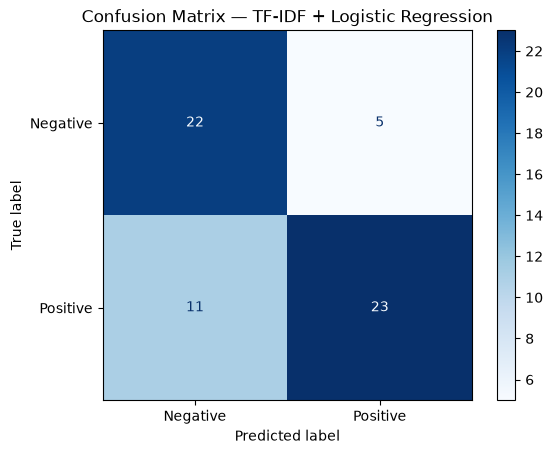

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[LABEL_MAP[0], LABEL_MAP[1]],
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix — TF-IDF + Logistic Regression")
plt.show()

## 10. Compare Bag of Words and TF-IDF

In [21]:
comparison = pd.DataFrame({
    "Model": ["Bag of Words + Logistic Regression", "TF-IDF + Logistic Regression"],
    "Accuracy": [bow_accuracy, accuracy]
}).sort_values("Accuracy", ascending=False)

comparison

,Model,Accuracy
0,Bag of Words + Logistic Regression,0.754098
1,TF-IDF + Logistic Regression,0.737705


## 11. Cross-Validation

Cross-validation gives a more stable estimate than relying on one train/test split alone.

In [22]:
cv_scores = cross_val_score(
    tfidf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("5-fold F1 scores:", np.round(cv_scores, 4))
print(f"Mean F1: {cv_scores.mean():.4f}")
print(f"Std F1 : {cv_scores.std():.4f}")

5-fold F1 scores: [0.7654 0.8696 0.8571 0.8308 0.5106]
Mean F1: 0.7667
Std F1 : 0.1330


## 12. Important Words and Phrases Learned by the Model

Logistic Regression coefficients can be used to inspect which TF-IDF features are most associated with each class.

In [23]:
def show_top_model_features(model, top_n=20):
    vectorizer = model.named_steps["tfidf"]
    classifier = model.named_steps["classifier"]

    feature_names = np.array(vectorizer.get_feature_names_out())
    coefficients = classifier.coef_[0]

    positive_idx = np.argsort(coefficients)[-top_n:][::-1]
    negative_idx = np.argsort(coefficients)[:top_n]

    positive = pd.DataFrame({
        "Positive feature": feature_names[positive_idx],
        "Weight": coefficients[positive_idx]
    })

    negative = pd.DataFrame({
        "Negative feature": feature_names[negative_idx],
        "Weight": coefficients[negative_idx]
    })

    return positive, negative

positive_features, negative_features = show_top_model_features(tfidf_model, top_n=20)
print("Top features associated with Positive label:")
display(positive_features)

print("Top features associated with Negative label:")
display(negative_features)

Top features associated with Positive label:


,Positive feature,Weight
0,great,0.847469
1,marvel,0.791709
2,infinity,0.752277
3,endgame,0.735446
4,infinity war,0.666530
5,war,0.666530
6,avengers,0.652863
7,best,0.616662
8,end,0.539073
9,the best,0.537017


Top features associated with Negative label:


,Negative feature,Weight
0,this movie,-0.822949
1,movie,-0.775984
2,this,-0.738088
3,boring,-0.643856
4,worst,-0.590719
5,the emoji,-0.559739
6,emoji movie,-0.516049
7,don watch,-0.515017
8,in,-0.511795
9,emoji,-0.471404


## 13. Keyword Extraction for One Review

This uses the trained TF-IDF vocabulary to return important unigrams/bigrams from a review. It is a simple, explainable keyword-extraction method suitable for the classical NLP version of the task.

In [24]:
def extract_keywords(text, model=tfidf_model, top_n=6):
    cleaned = clean_text(text)
    vectorizer = model.named_steps["tfidf"]
    vec = vectorizer.transform([cleaned])

    if vec.nnz == 0:
        return []

    feature_names = np.array(vectorizer.get_feature_names_out())
    row = vec.toarray()[0]
    nonzero = np.where(row > 0)[0]
    ranked = nonzero[np.argsort(row[nonzero])[::-1]]

    return feature_names[ranked[:top_n]].tolist()

sample_text = "The movie was visually amazing but the story was not good."
print("Text:", sample_text)
print("Keywords:", extract_keywords(sample_text))

Text: The movie was visually amazing but the story was not good.
Keywords: ['not good', 'was not', 'amazing', 'but the', 'movie was', 'the story']


## 14. Final Customer Feedback Analyzer

The function below gives the predicted sentiment, model confidence and important words/phrases for any new review.

In [25]:
def analyze_feedback(text, model=tfidf_model, top_n_keywords=6):
    cleaned = clean_text(text)
    pred_label = int(model.predict([cleaned])[0])
    probabilities = model.predict_proba([cleaned])[0]
    classes = model.named_steps["classifier"].classes_

    class_to_prob = dict(zip(classes, probabilities))
    confidence = float(class_to_prob[pred_label])

    return {
        "Original Feedback": text,
        "Cleaned Feedback": cleaned,
        "Predicted Label": pred_label,
        "Sentiment": LABEL_MAP.get(pred_label, str(pred_label)),
        "Confidence": round(confidence, 4),
        "Keywords": extract_keywords(text, model=model, top_n=top_n_keywords)
    }

examples = [
    "I absolutely loved the movie. The acting and ending were fantastic!",
    "The story was boring, messy and disappointing.",
    "The visuals were good but I did not like the weak plot."
]

for text in examples:
    result = analyze_feedback(text)
    print("\n" + "=" * 80)
    for key, value in result.items():
        print(f"{key}: {value}")


Original Feedback: I absolutely loved the movie. The acting and ending were fantastic!
Cleaned Feedback: i absolutely loved the movie the acting and ending were fantastic!
Predicted Label: 1
Sentiment: Positive
Confidence: 0.6008
Keywords: ['absolutely loved', 'fantastic', 'acting', 'movie the', 'loved', 'absolutely']

Original Feedback: The story was boring, messy and disappointing.
Cleaned Feedback: the story was boring messy and disappointing
Predicted Label: 0
Sentiment: Negative
Confidence: 0.5227
Keywords: ['messy and', 'messy', 'disappointing', 'boring', 'the story', 'story']

Original Feedback: The visuals were good but I did not like the weak plot.
Cleaned Feedback: the visuals were good but i did not like the weak plot
Predicted Label: 1
Sentiment: Positive
Confidence: 0.5804
Keywords: ['weak', 'not like', 'good but', 'did not', 'like the', 'did']


## 15. Error Analysis

Reading incorrect predictions helps us understand the model's limitations and identify difficult reviews.

In [26]:
results = pd.DataFrame({
    "review": X_test.values,
    "actual_label": y_test.values,
    "predicted_label": y_pred
})

results["actual_sentiment"] = results["actual_label"].map(LABEL_MAP)
results["predicted_sentiment"] = results["predicted_label"].map(LABEL_MAP)

errors = results[results["actual_label"] != results["predicted_label"]].copy()
print("Number of misclassified reviews:", len(errors))
errors.head(10)

Number of misclassified reviews: 16


,review,actual_label,predicted_label,actual_sentiment,predicted_sentiment
2,should have ended on infinity war,0,1,Negative,Positive
9,terrible 10 star users must have been paid,0,1,Negative,Positive
11,this is my own opinion but so many things that didn't make sense in that movie like so much stuff that could've been utilised in a better way and so many stupid things that were put on wrong hands...,1,0,Positive,Negative
15,no no and no again,1,0,Positive,Negative
20,i watched this movie with the lowest possible expectations and was pleasantly surprised this movie is boring hilarious depressing and deep depending on the scene joke watch it with an open mind an...,1,0,Positive,Negative
29,don't listen to the haters it's amazing! seriously this is the movie of the year!,1,0,Positive,Negative
32,this movie past over and beyond any expectation don't miss watching it will definitely watch it again and again endgame the name fits perfectly total respect,1,0,Positive,Negative
37,i'm shocked this is rated so poorly the movie was enjoyable and fun and great for kids was this a dramatic masterpiece sure to win awards? no of course not it was not intended to be that sort of m...,1,0,Positive,Negative
39,ok i went in expecting the absolute worst from this movie as i was purchasing my ticket however as i got sat down i began to reolise all my worries were for nothing i really liked the movie it kep...,1,0,Positive,Negative
45,endlame is disappointing and messy,0,1,Negative,Positive


## 16. Optional: Train the Final Model on All Available Data

After evaluation is complete, we can refit the selected pipeline using the whole dataset for later predictions.

In [27]:
final_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.98,
            sublinear_tf=True,
            max_features=10000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

final_model.fit(X, y)
print("Final model trained on all", len(X), "reviews.")

Final model trained on all 302 reviews.


## 17. Optional: Save the Model

Use `joblib` to save the complete pipeline, including TF-IDF and Logistic Regression.

In [28]:
import joblib

MODEL_FILE = "task16_customer_feedback_sentiment_model.joblib"
joblib.dump(final_model, MODEL_FILE)
print("Saved model as:", MODEL_FILE)

Saved model as: task16_customer_feedback_sentiment_model.joblib


## 18. Conclusion

This notebook demonstrates the main classical NLP concepts required for the supplied task:

- Text preprocessing and cleaning
- Bag of Words baseline
- TF-IDF numerical representation
- Unigrams and bigrams
- Logistic Regression text classification
- Sentiment prediction
- Keyword extraction
- Accuracy, Precision, Recall and F1 Score
- Confusion matrix
- Cross-validation
- Error analysis

### Dataset limitation
The supplied CSV has only `review` and `label`. Therefore, **supervised category/multi-label complaint classification is not possible from this dataset alone**. To add categories, the dataset would need an additional target such as `category` or `categories` (for example: payment, support, login, performance, UI).